<a href="https://colab.research.google.com/github/AlexanderEgorovNRNUMEPHI/AIM-projects/blob/main/ML/knn/main_task_Egorov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Большое практическое задание 1
# Классификация изображений цифр метрическими методами

## курс "Машинное обучение 1", программа AIMasters, 2022

## Студент: <Егоров Александр Сергеевич>

## Введение

Данное задание направлено на ознакомление с метрическими алгоритмами классификации, а также методами работы с изображениями. В задании вам будет необходимо:

1. Написать на языке Python собственные реализации метода ближайших соседей и кросс-валидации. Реализации должны соответствовать спецификации, описанной в прилагающихся модулях.     
    Частично проверить правильность выполнения своих реализаций можно с помощью системы ejudge в соответствующем соревновании.
    **Внимание.** Прохождение всех тестов в соревновании не гарантирует правильность решения.


2. Провести описанные ниже эксперименты с датасетом изображений цифр MNIST, описать полученые результаты и ответить на предложенные вопросы.


3. Подготовить отчёт о проделанной работе. Удалите черновые выводы, оставьте только тот код, который является ответом к пунктам задания. Сохраните ноутбук в форматах .ipynb и .html одновременно.

    **Замечание.** Чтобы экспорировать jupyter notebook в .html нужно выбрать:
    `File -> Download as -> HTML (.html).`
    Для экспорта notebook в .html в Google Colab, воспользуйтесь [следующим кодом](https://gist.github.com/vbugaevskii/b9c6181f2ad83e11f5b9c92d315cb2de).
Большая просьба: подписывайте свой отчет (в названии файла и внутри ноутбука).


4. В систему проверки необходимо сдать отчёт в обоих форматах и .zip архив с написанными модулями.

    Большая просьба: jupyter notebook и html файл не запаковывать в архив, а сдавать отдельно.

### Некоторые полезные советы

1. Для того, чтобы не перезагружать jupyter notebook каждый раз после того, как вы внесли изменения в модуль `knn`, можно добавить ячейку с таким содержимым:
     
```
    %load_ext autoreload
    
    %autoreload 2
```
   
2. Не нужно копировать свой код из модулей в jupyter notebook, пользуйтесь им, как если бы это была библиотека. Для этого поместите директорию `knn` рядом с notebook-ом. Пример, как может выглядеть содержимое вашей рабочей директории:

```
    tree
    ---knn
    ------__init__.py
    ------classification.py
    ------distances.py
    ------model_selection.py
    ------nearest_neighbors.py
    ---tests
    ------__init__.py
    ------test_classification.py
    ------test_distances.py
    ------test_model_selection.py
    ------test_nearest_neigbours.py
    experiments.ipynb
```

## Реализация алгоритмов (10 баллов)

Прототипы функций должны строго соответствовать прототипам, описанным в спецификации и проходить
все выданные тесты. Задание, не проходящее все выданные тесты, приравнивается к невыполненному. При
написании **необходимо пользоваться** стандартными средствами языка Python и библиотекой numpy. Библиотеками scipy и scikit-learn пользоваться **запрещено**, если это не обговорено отдельно в пункте задания. Для
экспериментов в бонусной части разрешается пользоваться любыми открытыми библиотеками, реализующими
алгоритмы обработки изображений.

Среди предоставленных файлов должны быть следующие модули и функции в них

1. Модуль `knn.distances` с реализацией функции для вычисления расстояния:
    1. `euclidean_distance(X, Y)` — реализация евклидова расстояния с заданными свойствами;
    2. `cosine_distance(X, Y)` — реализация косинусного расстояния с заданными свойствами;


2. Модуль `knn.nearest_neighbors`, содержащий собственную реализацию поиска ближайших соседей.
    
    Класс `NearestNeighborsFinder` с методами:
      1. `__init__(self, n_neighbors, metric="euclidean")` — конструктор (инициализатор) класса;
      2. `fit(self, X, y=None)` — обучение алгоритма;
      3. `kneighbors(self, X, return_distance=False)` — поиск ближайших соседей.


3. Модуль `knn.classification`, содержащий собственную реализацию классификатора на основе метода ближайших соседей.

    Класс `KNNClassifier` с методами:
    
    1. `__init__(self, n_neighbors, algorithm=’my_own’, metric=’euclidean’, weights=’uniform’)` — конструктор (инициализатор) класса;
    2. `fit(self, X, y=None)` — обучение алгоритма;
    3. `kneighbors(self, X, return_distance=False)` — поиск ближайших соседей;
    4. `predict(self, X)` — редсказание на новых данных;
    5. `_predict_precomputed(self, indices, distances)` — вспомогательный метод.
    
   Класс `BatchedKNNClassifier`, полезный для работы с большими выборками, с методами:
   
    1. `__init__(self, n_neighbors, algorithm=’my_own’, metric=’euclidean’, weights=’uniform’, batch_size=None)` — конструктор (инициализатор) класса
    2. `kneighbors(self, X, return_distance=False)` — поиск ближайших соседей, разбитый на несколько итераций по батчам
    3. `set_batch_size(self, batch_size)` — метод для выставления нового значения размера батча


4. Модуль `knn.model_selection` с реализациями функций для применения кросс-валидации:

    1. `knn_cross_val_score(X, y, k_list, scoring, cv=None, **kwargs)` — функция для измерения качества на кросс-валидации.

Ожидается, что реализациия всех классов и функций будет максимально эффективной. Дополнительно вам предоставлены открытые unit-тесты, которые находятся рядом с модулем `knn` в директории `tests` Чтобы запустить тесты в консоли требуется выполнить одну из команд:


```
$ python -m unittest                            # запуск всех тестов
$ python -m unittest tests/test_distances.py    # запуск конкретных тестов
```

## Эксперименты (15 баллов)

Здесь вы можете заимпортировать всё, что вам потребуется для экспериментов:

In [ ]:
%load_ext autoreload

%autoreload 2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.metrics import accuracy_score, confusion_matrix
from knn.distances import euclidean_distance, cosine_distance
from knn.classification import BatchedKNNClassifier
from knn.model_selection import knn_cross_val_score
from sklearn.model_selection import KFold


ModuleNotFoundError: No module named 'knn'

### 1. Загрузка даннных

Эксперименты этого задания необходимо проводить на датасете MNIST. Загрузить датасет можно при помощи функции `sklearn.datasets.fetch_openml("mnist_784")` или скачать вручную с сайта
http://yann.lecun.com/exdb/mnist/. Датасет необходимо разбить на обучающую выборку (первые 60 тыс.
объектов) и тестовую выборку (10 тыс. последних объектов).

In [ ]:
data = datasets.fetch_openml("mnist_784")

In [ ]:
x_train = np.asarray(data.data.iloc[:60000, :], dtype=int)
y_train = np.asarray(data.target[:60000], dtype=int)


x_test = np.asarray(data.data.iloc[-10000:, :], dtype=int)
y_test = np.asarray(data.target[-10000:], dtype=int)

### 2. Исследование скорости методов поиска (4 балла)

Исследуйте, какой алгоритм поиска ближайших соседей будет быстрее работать в различных ситуациях.

Измерьте для каждого алгоритма поиска (`kd_tree`, `ball_tree`, `brute` и `my_own`) время нахождения 5 ближайших соседей для каждого объекта тестовой выборки по евклидовой метрике. Выберите подмножество признаков, по которому будет считаться расстояние, размера 10, 20, 100 (подмножество признаков выбирается один раз для всех объектов, случайно).

**Замечание.** Для оценки времени долго работающих функций можно пользоваться либо функциями из
модуля time, либо magic-командой %time, которая запускает код лишь один раз.

In [ ]:
algorithms = ['kd_tree', 'ball_tree', 'brute', 'my_own']
sizes = [10, 20, 100]
feature_subset={}
for size in sizes:
    feature_subset[size] = np.random.randint(1, data.data.shape[1], size)

results = pd.DataFrame(columns=['algorithm', 'feature_subset_size', 'experiment_time'])


for algorithm in algorithms:
    for n in feature_subset:
        classifier = BatchedKNNClassifier(
            n_neighbors=5,
            algorithm=algorithm,
        )

        classifier.fit(x_train[:, feature_subset[n]])
        start_time = time.monotonic()

        idnx = classifier.kneighbors(x_test[:, feature_subset[n]])

        experiment_time = time.monotonic() - start_time

        iteration = pd.DataFrame({'algorithm': [algorithm], 'feature_subset_size': [n],
                                  'experiment_time': [experiment_time]})

        results = results.append(iteration, ignore_index=True)

        print('algorithm:', algorithm, 'feature_subset_size:', n, 'experiment_time:', experiment_time)

algorithm: kd_tree feature_subset_size: 10 experiment_time: 0.7817508880000048
algorithm: kd_tree feature_subset_size: 20 experiment_time: 2.223674676999998
algorithm: kd_tree feature_subset_size: 100 experiment_time: 95.596573983
algorithm: ball_tree feature_subset_size: 10 experiment_time: 2.826125951000023
algorithm: ball_tree feature_subset_size: 20 experiment_time: 12.872713933
algorithm: ball_tree feature_subset_size: 100 experiment_time: 99.68761182900002
algorithm: brute feature_subset_size: 10 experiment_time: 9.035485504999997
algorithm: brute feature_subset_size: 20 experiment_time: 8.599663651000014
algorithm: brute feature_subset_size: 100 experiment_time: 9.556394916999977
algorithm: my_own feature_subset_size: 10 experiment_time: 44.10854265199998
algorithm: my_own feature_subset_size: 20 experiment_time: 28.420273586999997
algorithm: my_own feature_subset_size: 100 experiment_time: 149.25059105199995


#### Приведите график / таблицу с результатами вашего эксперимента

In [ ]:
results.pivot(index='algorithm', columns='feature_subset_size')

experiment_time                       
feature_subset_size             10         20          100
algorithm                                                 
ball_tree                  2.826126  12.872714   99.687612
brute                      9.035486   8.599664    9.556395
kd_tree                    0.781751   2.223675   95.596574
my_own                    44.108543  28.420274  149.250591

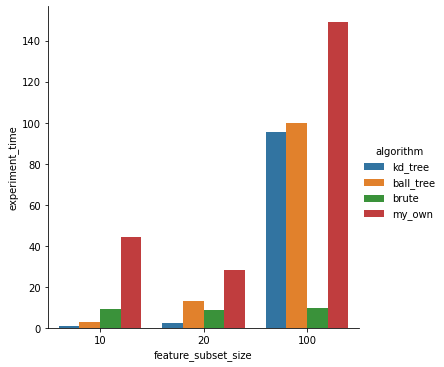

In [ ]:
sns.catplot(data=results, x="feature_subset_size", y="experiment_time", hue="algorithm", kind='bar')


#### Ответьте на следующие вопросы

1. Какой алгоритм сработал быстрее всего для каждого из размера подвыборок? Ожидали ли вы такие результаты до проведения эксперимента?

   **Быстрее всего отработал алгоритм brute. my_own показывает себя хуже скорее всего из-за неэффективной реализации.**

2. Приведите теоретическую сложность каждого из алгоритмов поиска. Согласуется ли время работы алгоритмов на практике с их теоретической вычислительной сложностью? Как вы думаете, почему?

**1) Алгоритм kd_tree очень эффективен при размерности признакового пространства в пределах примерно 20. Его теоретическая сложность по времени оценивается как O(D $\log$ n), где D-размерность признакового пространства, n - длина входа(количество экземпляров). При увеличении D выше 20 его эффективность ухудшается до O(Dn). Это подтверждается данным экспериментом, есть согласие с теорией.**

**2) Алгоритм ball_tree имеет сложность по времени O(D $\log$ n). ball_tree и kd_tree работают более эффективно с данными, которые имеют меньшую внутреннюю размерность, в то время как brute от этого не зависит. Можно предположить, что в данной задаче внутренняя размерность довольно высокая. Предполагаю, что это связано с тем, что мы берем случайные подмножества пикселей.**

**3)brute имеет оценку по времени O(Dn), так как D все еще довольно мало разница практически незаметна**

**4)my_own по идее должно иметь оценку по времени O(Dn), но видимо неэффективно реализован**

**Количество соседей k влияет на время запроса алгоритмов ball_tree и kd_tree и поэтому они должны работать медленнее при больших k, при этом на brute этот параметр с точки зрения скорости влиять не должен.**

3. Какой алгоритм исходя из результатов эксперимента следует использовать в дальнейшем? Выберите алгоритм поиска соседей, который вы будете использовать во всех экспериментах ниже.

**Буду использовать алгоритм brute, так как он не зависит от количества соседей, внутренней размерности данных и легче интерпретируем**

### 3. Исследование зависимости точности алгоритма на кросс-валидации (4 балла)


Оцените по кросс-валидации с 3 фолдами точность (долю правильно предсказанных ответов) алгоритма k ближайших соседей в зависимости от следующих факторов:
* количество соседей k от 1 до 10
* используется евклидова или косинусная метрика

In [ ]:
cv = KFold(n_splits=3)

euclidean_score = knn_cross_val_score(
    x_train,
    y_train,
    np.arange(1,11),
    'accuracy',
    cv=cv,
    algorithm='brute',
    metric='euclidean',
)


cosine_score = knn_cross_val_score(
    x_train,
    y_train,
    np.arange(1,11),
    'accuracy',
    cv=cv,
    algorithm='brute',
    metric='cosine',
)



In [ ]:
euclidean_score_mean = [np.mean(x) for x in euclidean_score.values()]
euclidean_score_std = [np.std(x) for x in euclidean_score.values()]

cosine_score_mean = [np.mean(x) for x in cosine_score.values()]
cosine_score_std = [np.std(x) for x in cosine_score.values()]

#### Нарисуйте график зависимости точности от количества соседей по каждой метрике

Text(0.5, 1.0, 'Сравнение точности предсказания на кроссвалидации в зависимости от k соседей')

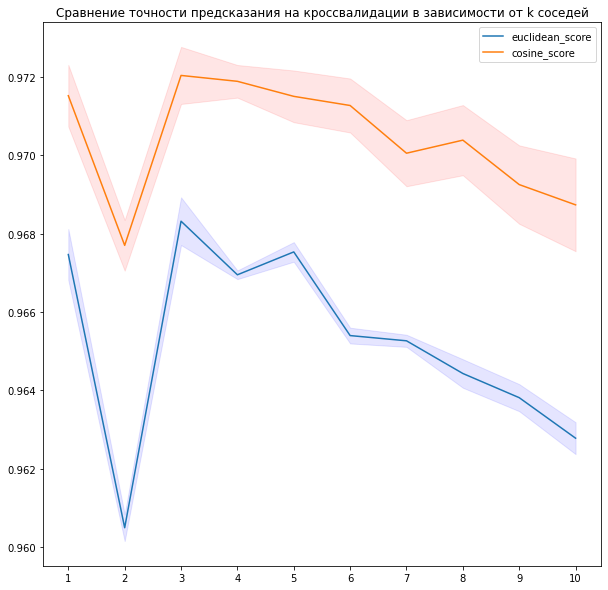

In [ ]:
ci_euclidean = 1.96*np.array(euclidean_score_std)/np.sqrt(10)
ci_cosine = 1.96*np.array(cosine_score_std)/np.sqrt(10)

fig, ax = plt.subplots(figsize=(10,10))
line, = ax.plot(np.arange(1,11), euclidean_score_mean)
plt.xticks(np.arange(1,11))
line.set_label('euclidean_score')
ax.legend()
ax.fill_between(np.arange(1,11), (euclidean_score_mean-ci_euclidean),
                (euclidean_score_mean+ci_euclidean), color='b', alpha=.1)
line2, = ax.plot(np.arange(1,11), cosine_score_mean)
line2.set_label('cosine_score')
ax.legend()
ax.fill_between(np.arange(1,11), (cosine_score_mean-ci_cosine),
                (cosine_score_mean+ci_cosine), color='r', alpha=.1)
plt.title('Сравнение точности предсказания на кроссвалидации в зависимости от k соседей')

#### Ответьте на следующие вопросы

1. По результатам эксперимента, какие гиперпараметры вы считаете наиболее оптимальными? Обоснуйте свой выбор (например, если у вас несколько наборов параметров с высоким качеством, обоснуйте как вы выберите среди этих наборов один).

   **Оптимальный результат по кроссвалидации достигается при k = 3. Однако, малое количество ближайших соседей ведет к неустойчивости алгоритма и возможному переобучению. Считаю, что стоит выбрать 5 ближайших соседей как вариант с хорошим значением метрики и большей стабильностью**


2. Какая метрика лучше себя показала в экспериментах? Можете ли вы объяснить, почему?

  **Лучше себя показала косинусная метрика. Полагаю, что это связано со спецификой данных: высокая разреженность. Как известно, на разреженных данных косинусное расстояние предпочтительнее.**
    
   
2. Есть ли на графике зависимости точности от количество соседей "выбросы", резкие падения/повышения качества для одного значения k по сравнению с соседними? Если да, предположите причину появления этих выбросов.

    **Выбросы происходят на малых k. При таких k алгоритм неустойчив к шумовым выбросам(предсказание делается на очень малом количестве информации). Скорее всего хороших результат по метрике на k=1 это просто совпадение.**

### 3. Исследование зависимости точности взвешенного алгоритма на кросс-валидации (4 балла)

По результатам предыдущего эксперимента выберите метрику, которую вы будете использовать в этом эксперименте.

Оцените по кросс-валидации с 3 фолдами точность (долю правильно предсказанных ответов) взвешенного алгоритма k ближайших соседей в зависимости от количество соседей k (от 1 до 10).

Голос объекта положите равным `1 / (distance + eps)`, где `eps` = `1e-5`.

In [ ]:
cv = KFold(n_splits=3)

cosine_score_weight = knn_cross_val_score(
    x_train,
    y_train,
    np.arange(1,11),
    'accuracy',
    cv=cv,
    algorithm='brute',
    metric='cosine',
    weights='distance',

)



In [ ]:
cosine_score_mean_weight = [np.mean(x) for x in cosine_score_weight.values()]
cosine_score_std_weight = [np.std(x) for x in cosine_score_weight.values()]

#### Нарисуйте график зависимости точности от количества соседей

Text(0.5, 1.0, 'Сравнение точности предсказания на кроссвалидации взвешенного и невзвешенного алгоритмов в зависимости от k соседей')

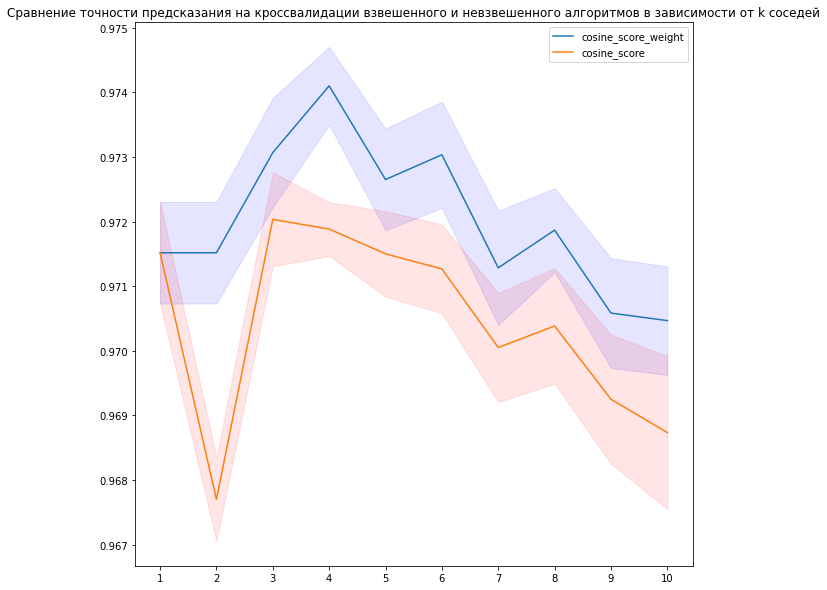

In [ ]:
ci_cosine_weight = 1.96*np.array(cosine_score_std_weight)/np.sqrt(10)
ci_cosine = 1.96*np.array(cosine_score_std)/np.sqrt(10)


fig, ax = plt.subplots(figsize=(10,10))
line, = ax.plot(np.arange(1,11), cosine_score_mean_weight)
plt.xticks(np.arange(1,11))
line.set_label('cosine_score_weight')
ax.legend()
ax.fill_between(np.arange(1,11), (cosine_score_mean_weight-ci_cosine_weight),
                (cosine_score_mean_weight+ci_cosine_weight), color='b', alpha=.1)

line2, = ax.plot(np.arange(1,11), cosine_score_mean)
line2.set_label('cosine_score')
ax.legend()
ax.fill_between(np.arange(1,11), (cosine_score_mean-ci_cosine),
                (cosine_score_mean+ci_cosine), color='r', alpha=.1)
plt.title('Сравнение точности предсказания на кроссвалидации взвешенного и невзвешенного алгоритмов в зависимости от k соседей')

#### Ответьте на следующие вопросы

1. По результатам эксперимента, какие гиперпараметры вы считаете наиболее оптимальными? Обоснуйте свой выбор.

  **Результат не изменился значительно. Считаю более оптимальным использовать алгоритм без развесовки, так как усложнение модели без явной причины может привести к переобучению на тестовой выборке. Кроме того это может приводить к дополнительным багам, если говорить о продовом выпуске.**


2. Сравните результаты взвешенного алгоритма с невзвешенным. Объясните разницу/отсутствие разницы в результатах.

   **Разницы практически нет. Возможно разница по дистанции между соседями невелика, поэтому алгоритм отрабатывает как юниформный**

### 4. Применение алгоритма и интерпретация ошибок (3 балла)

1. Примените лучший алгоритм к исходной обучающей и тестовой выборке и посчитайте точность классификации. Сравните с точностью по кросс-валидации. Опишите ваши результаты.

In [ ]:
classifier = BatchedKNNClassifier(
    n_neighbors=5,
    algorithm='brute',
    metric='cosine',
)
classifier.fit(x_train, y_train)
prediction = classifier.predict(x_test)

In [ ]:
print('Качество на кросс-валидации:', cosine_score_mean[4])
print('Качество на тесте:', accuracy_score(y_test, prediction))

Качество на кросс-валидации: 0.9714999999999999
Качество на тесте: 0.973


**Результат на тесте сравним с результатом на кроссвалидации. Это хорошо, так как не бросается в глаза явное переобучение или недообучение. Качество составляет приерно 97%, для достаточно простого алгоритма.**

2. Постройте и проанализируйте матрицу ошибок (confusion matrix), используйте функцию `sklearn.metrics.confusion_matrix`. Визуализируйте несколько объектов из тестовой выборки, на которых были допущены ошибки. Проанализируйте и укажите их общие черты.

In [ ]:
confusion_matrix(y_test, prediction)


array([[ 975,    1,    0,    0,    0,    0,    3,    1,    0,    0],
       [   0, 1131,    2,    0,    0,    0,    2,    0,    0,    0],
       [  10,    2, 1006,    1,    1,    0,    0,    8,    4,    0],
       [   3,    1,    3,  975,    1,    9,    0,    6,    9,    3],
       [   3,    2,    0,    0,  943,    0,    6,    1,    2,   25],
       [   6,    0,    0,    7,    1,  860,    7,    2,    6,    3],
       [   4,    2,    0,    0,    2,    2,  948,    0,    0,    0],
       [   2,   12,    6,    0,    0,    0,    0,  992,    0,   16],
       [   6,    3,    3,    9,    3,    5,    4,    3,  934,    4],
       [   9,    8,    2,    6,    4,    3,    1,    6,    4,  966]])

**Алгоритм отработал с очень приличным качеством на тестовой выборке. Чаще всего он путал 4 с 9, 1 с 7, что неудивительно, так как они пишутся довольно похоже.**

## Бонус 1. Размножение обучающей выборки (3 балла)

Размножьте обучающую выборку с помощью поворотов, смещений, применений гауссовского фильтра и морфологических операций. Разрешается использовать библиотеки для работы с изображениями. Подобрать по кросс-валидации с 3 фолдами параметры преобразований. Рассмотреть следующие параметры для преобразований и их комбинации:
1. Величина поворота: 5, 10, 15 (в каждую из двух сторон)
2. Величина смещения: 1, 2, 3 пикселя (по каждой из двух размерностей)
3. Дисперсия фильтра Гаусса: 0.5, 1, 1.5
4. Морфологические операции: эрозия, дилатация, открытие, закрытие с ядром 2

Проанализируйте, как изменилась матрица ошибок, какие ошибки алгоритма помогает исправить каждое
преобразование.

**Замечание.** Не обязательно хранить все обучающие выборки в процессе эксперимента. Достаточно вычислить ближайших соседей по каждой из выборок, а затем выбрать из них ближайших соседей.

**Замечание по дизайну эксперимента**. В этой части вам предлагается самим выбрать дизайн эксперимента. Перебор всевоможных комбинаций преобразований может быть затруднительным, в то время как жадный выбор преобразований уже даст улучшение в качестве.

In [ ]:
# Здесь и во всех исследования ниже эксперименты проводятся для 5 ближайших соседей
# (принимается,что этот параметр оптимален по результатам выше. В целом, интересно
# было бы и подбирать количество соседей по расширенной выборке, но требуется много времени на расчеты)
from skimage.transform import rotate

angles=[-5, 5,-10, 10,-15,15]
result_rotate={}

for angle in angles:
    rot_x_train=[]
    for x in x_train:
        rot_img = rotate(x.reshape(28,28), angle)
        rot_x_train.append(rot_img.flatten())
    x_train_rot = np.concatenate([x_train, np.array(rot_x_train)], axis=0)
    y_train_rot = np.concatenate([y_train, y_train])
    cv = KFold(n_splits=3)
    cosine_score = knn_cross_val_score(
        x_train_rot,
        y_train_rot,
        [5],
        'accuracy',
        cv=cv,
        algorithm='brute',
        metric='cosine',

    )
    result_rotate[angle]=np.array(cosine_score[5]).mean()




In [ ]:
result_rotate

{-5: 0.9839916666666667,
 5: 0.9838083333333333,
 -10: 0.9791250000000001,
 10: 0.9793416666666667,
 -15: 0.9717749999999999,
 15: 0.972325}

In [ ]:
from skimage.filters import gaussian
sigmas=[0.5, 1, 1.5]
result_gaussian={}

for sigma in sigmas:
    x_gauss=gaussian(x_train, sigma=sigma)
    x_train_gauss=np.concatenate([x_train, x_gauss], axis=0)
    y_train_gauss = np.concatenate([y_train, y_train])
    cv = KFold(n_splits=3)
    cosine_score = knn_cross_val_score(
        x_train_gauss,
        y_train_gauss,
        [5],
        'accuracy',
        cv=cv,
        algorithm='brute',
        metric='cosine',

    )
    result_gaussian[sigma]=np.array(cosine_score[5]).mean()



In [ ]:
result_gaussian

{0.5: 0.9818833333333333, 1: 0.8166583333333333, 1.5: 0.6769916666666668}

In [ ]:
from skimage.morphology import erosion, dilation, opening, closing, square

random_indices=np.random.choice(x_train.shape[0], 100, replace=False)
x_for_manipulation=x_train[random_indices]
result_morph={}
morph_x_train=[]

# В этих расчетах используем преобразования только для 100 случайных картинок, так как вычисления затратные по времени.

# erosion
for x in x_for_manipulation:
    morph_img = erosion(x.reshape(28,28), square(2))
    morph_x_train.append(morph_img.flatten())
morph_x_train = np.concatenate([x_train, np.array(morph_x_train)], axis=0)
y_train_morph = np.concatenate([y_train, y_train[random_indices]])
cv = KFold(n_splits=3)
cosine_score = knn_cross_val_score(
    morph_x_train,
    y_train_morph,
    [5],
    'accuracy',
    cv=cv,
    algorithm='brute',
    metric='cosine',

)
result_morph['erosion']=np.array(cosine_score[5]).mean()
print('erosion:', result_morph)

result_morph={}
morph_x_train=[]

# dilation
for x in x_for_manipulation:
    morph_img = dilation(x.reshape(28,28), square(2))
    morph_x_train.append(morph_img.flatten())
morph_x_train = np.concatenate([x_train, np.array(morph_x_train)], axis=0)
y_train_morph = np.concatenate([y_train, y_train[random_indices]])
cv = KFold(n_splits=3)
cosine_score = knn_cross_val_score(
    morph_x_train,
    y_train_morph,
    [5],
    'accuracy',
    cv=cv,
    algorithm='brute',
    metric='cosine',

)
result_morph['dilation']=np.array(cosine_score[5]).mean()
print('dilation:', result_morph)


result_morph={}
morph_x_train=[]

# opening
for x in x_for_manipulation:
    morph_img = opening(x.reshape(28,28), square(2))
    morph_x_train.append(morph_img.flatten())
morph_x_train = np.concatenate([x_train, np.array(morph_x_train)], axis=0)
y_train_morph = np.concatenate([y_train, y_train[random_indices]])
cv = KFold(n_splits=3)
cosine_score = knn_cross_val_score(
    morph_x_train,
    y_train_morph,
    [5],
    'accuracy',
    cv=cv,
    algorithm='brute',
    metric='cosine',

)
result_morph['opening']=np.array(cosine_score[5]).mean()
print('opening:', result_morph)


result_morph={}
morph_x_train=[]

# closing
for x in x_for_manipulation:
    morph_img = closing(x.reshape(28,28), square(2))
    morph_x_train.append(morph_img.flatten())
morph_x_train = np.concatenate([x_train, np.array(morph_x_train)], axis=0)
y_train_morph = np.concatenate([y_train, y_train[random_indices]])
cv = KFold(n_splits=3)
cosine_score = knn_cross_val_score(
    morph_x_train,
    y_train_morph,
    [5],
    'accuracy',
    cv=cv,
    algorithm='brute',
    metric='cosine',

)
result_morph['closing']=np.array(cosine_score[5]).mean()
print('closing:', result_morph)

erosion: {'erosion': 0.9714642049563015}
dilation: {'dilation': 0.9714642032952042}
opening: {'opening': 0.9714974833802353}
closing: {'closing': 0.9715307618041692}


**Rotation на +- 5 градусов демонстрирует хорошую прибавку в точности на кроссвалидации. Поворот на больший угол может быть хуже, так как цифры уже могут быть немного смещены и еще большее смещение, может,например, приводить к путанице 6 и 9.
Фильтр гаусса тоже дает сравнимую прибавку в точности, но кажется оптимальнее использовать rotation как более простой подход.
Морфологические подходы не показывают существенного улучшения, это может быть связано с тем, что они применяются только к ограниченной подвыборке из-за экономии времени расчета.**

In [ ]:
# Посмотрим на качество предсказаний на тесте при добавления rotation на 5 градусов
rot_x_train=[]
angle=5
for x in x_train:
    rot_img = rotate(x.reshape(28,28), angle)
    rot_x_train.append(rot_img.flatten())
x_train_rot = np.concatenate([x_train, np.array(rot_x_train)], axis=0)
y_train_rot = np.concatenate([y_train, y_train])
cv = KFold(n_splits=3)
cosine_score = knn_cross_val_score(
    x_train_rot,
    y_train_rot,
    [5],
    'accuracy',
    cv=cv,
    algorithm='brute',
    metric='cosine',

)
result_rotate[angle]=np.array(cosine_score[5]).mean()

In [ ]:
classifier = BatchedKNNClassifier(
    n_neighbors=5,
    algorithm='brute',
    metric='cosine',
)
classifier.fit(x_train_rot, y_train_rot)
prediction = classifier.predict(x_test)

In [ ]:
print('Качество на кросс-валидации:', result_rotate[5])
print('Качество на тесте:', accuracy_score(y_test, prediction))

In [ ]:
confusion_matrix(y_test, prediction)


**Результат улучшился, теперь некоторые цифры, которые писались похоже(например 1 и 7) легче определяются алгоритмом**

## Бонус 2. Размножение тестовой выборки (2 балла)

Реализуйте предложенный на семинаре алгоритм, основанный на преобразовании объектов тестовой выборки.
Проверьте то же самое множество параметров, что и в предыдущем пункте.

Проанализируйте как изменилась матрица ошибок, какие ошибки алгоритма помогает исправить каждое
преобразование.

In [ ]:
## your code here ##

## Бонус 3. Сравнение подходов (1 балл)

Если вы реализовали оба подхода, сравните их между собой.

1. Какой подход даёт больший выигрыш в качестве и почему?

    *ваш ответ*
    

2. Есть ли какие-то преимущества у худшего по качеству подхода по сравнению с лучшим?

    *ваш ответ*